<a href="https://colab.research.google.com/github/chin0308/Research_Papers/blob/main/convection_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow numpy pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

[Adam] Epoch 0: Loss = 0.396811
[Adam] Epoch 300: Loss = 0.002209
[Adam] Epoch 600: Loss = 0.001543
[Adam] Epoch 900: Loss = 0.001376
[Adam] Epoch 1200: Loss = 0.001289
[Adam] Epoch 1500: Loss = 0.001174
[Adam] Epoch 1800: Loss = 0.001083
[Adam] Epoch 2100: Loss = 0.001067
[Adam] Epoch 2400: Loss = 0.001055
[Adam] Epoch 2700: Loss = 0.001043
[L-BFGS] Starting fine-tuning...
Final Test MSE: 0.40036759
[Adam] Epoch 0: Loss = 0.731510
[Adam] Epoch 300: Loss = 0.205581
[Adam] Epoch 600: Loss = 0.087225
[Adam] Epoch 900: Loss = 0.078726
[Adam] Epoch 1200: Loss = 0.077299
[Adam] Epoch 1500: Loss = 0.076570
[Adam] Epoch 1800: Loss = 0.076014
[Adam] Epoch 2100: Loss = 0.075772
[Adam] Epoch 2400: Loss = 0.075632
[Adam] Epoch 2700: Loss = 0.075513
[L-BFGS] Starting fine-tuning...
Final Test MSE: 0.39208165


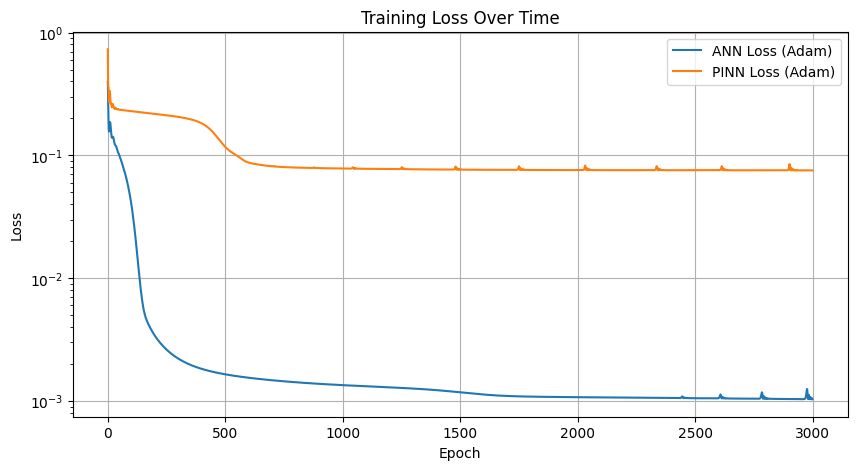

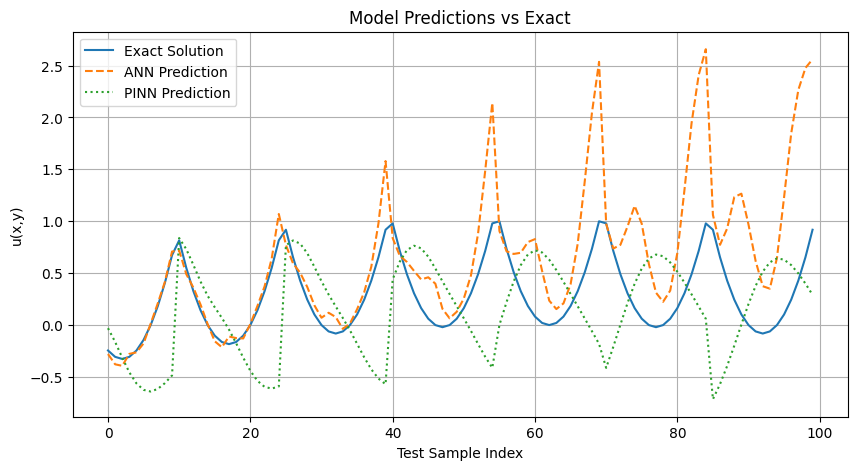

In [3]:
# Import core libraries
import numpy as np                     # Numerical computing
import pandas as pd                   # Data handling
import torch                          # Deep learning framework
import torch.nn as nn                 # Neural network module
import matplotlib.pyplot as plt       # Plotting library

# Set random seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Load dataset from CSV
df = pd.read_csv("/content/modified_diffusion_data.csv")
X = df[['x', 'y']].values             # Input features: spatial coordinates
u_exact = df['u_exact'].values        # Exact scalar field solution
u_noisy = df['u_noisy'].values        # Noisy solution used for training

# Split dataset into training and test sets
X_train, X_test = X[:50], X[50:150]
y_train, y_test = u_noisy[:50], u_exact[50:150]   # Noisy for training, exact for testing

# Convert to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_test_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

# Generate collocation points for PDE residual computation (PINN)
n_collocation = 1000
x_colloc = 2 * np.random.rand(n_collocation, 2) - 1     # Uniformly sampled in domain [-1, 1]^2
x_colloc_torch = torch.tensor(x_colloc, dtype=torch.float32)

# Define a simple feedforward neural network (shared for ANN and PINN)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),       # Input: x, y
            nn.Tanh(),              # Nonlinear activation
            nn.Linear(64, 64),      # Hidden layer
            nn.Tanh(),
            nn.Linear(64, 1)        # Output: scalar u(x,y)
        )
    def forward(self, x):
        return self.net(x)

# Define PINN loss: residual of 2D convection-diffusion equation
def pinn_loss(model, x):
    x.requires_grad = True                         # Enable automatic differentiation
    u = model(x)                                   # Forward pass

    grads = torch.autograd.grad(outputs=u, inputs=x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grads[:, 0:1]                            # ∂u/∂x
    u_y = grads[:, 1:2]                            # ∂u/∂y

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    D = 0.01                                       # Diffusion coefficient
    v_x, v_y = 1.0, 0.5                            # Convection velocities

    convection = v_x * u_x + v_y * u_y             # v · ∇u
    diffusion = D * (u_xx + u_yy)                  # D∇²u

    residual = -diffusion + convection             # Steady-state PDE residual
    return torch.mean(residual**2)                 # Mean squared residual (loss)

# Enforce boundary condition u = x² - y² on corners
def boundary_loss(model):
    xb = torch.tensor([[x, y] for x in [-1, 1] for y in [-1, 1]], dtype=torch.float32)
    ub = xb[:, 0]**2 - xb[:, 1]**2                  # True BC values
    ub = ub.view(-1, 1)
    return torch.mean((model(xb) - ub) ** 2)        # MSE boundary loss

# Unified training loop for ANN and PINN
def train_hybrid(model, X_train, y_train, X_test, y_test, x_colloc, use_pinn=True, pde_weight=20.0, bc_weight=5.0):
    mse = nn.MSELoss()                              # Supervised loss function
    adam = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []

    # Stage 1: Train using Adam optimizer
    for epoch in range(3000):
        model.train()
        adam.zero_grad()
        pred = model(X_train)
        data_loss = mse(pred, y_train)

        # Add physics-based losses if using PINN
        if use_pinn:
            pde = pinn_loss(model, x_colloc)
            bc = boundary_loss(model)
            loss = data_loss + pde_weight * pde + bc_weight * bc
        else:
            loss = data_loss

        loss.backward()
        adam.step()
        losses.append(loss.item())

        if epoch % 300 == 0:
            print(f"[Adam] Epoch {epoch}: Loss = {loss.item():.6f}")

    # Stage 2: Fine-tuning with L-BFGS optimizer for higher precision
    def closure():
        lbfgs.zero_grad()
        pred = model(X_train)
        data_loss = mse(pred, y_train)
        if use_pinn:
            pde = pinn_loss(model, x_colloc)
            bc = boundary_loss(model)
            loss = data_loss + pde_weight * pde + bc_weight * bc
        else:
            loss = data_loss
        loss.backward()
        return loss

    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-9)
    print("[L-BFGS] Starting fine-tuning...")
    lbfgs.step(closure)

    # Evaluate final test performance
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test).numpy()
        mse_error = np.mean((y_test.numpy() - pred_test) ** 2)
    print(f"Final Test MSE: {mse_error:.8f}")
    return pred_test, losses

# --- Train Models ---

# Train Artificial Neural Network (without physics)
ann = Net()
ann_pred, ann_losses = train_hybrid(ann, X_train_torch, y_train_torch, X_test_torch, y_test_torch, x_colloc_torch, use_pinn=False)

# Train Physics-Informed Neural Network (with PDE + BC losses)
pinn = Net()
pinn_pred, pinn_losses = train_hybrid(pinn, X_train_torch, y_train_torch, X_test_torch, y_test_torch, x_colloc_torch, use_pinn=True)

# --- Visualization ---

# Training loss plot
plt.figure(figsize=(10,5))
plt.plot(ann_losses, label="ANN Loss (Adam)")
plt.plot(pinn_losses, label="PINN Loss (Adam)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# Prediction comparison on test set
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Exact Solution")
plt.plot(ann_pred, '--', label="ANN Prediction")
plt.plot(pinn_pred, ':', label="PINN Prediction")
plt.xlabel("Test Sample Index")
plt.ylabel("u(x,y)")
plt.title("Model Predictions vs Exact")
plt.legend()
plt.grid(True)
plt.show()
